In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Componentes
compounds = pd.read_csv('screened_compounds_rel_8.5.csv')

print(compounds.shape)
print(compounds.head())
print(compounds.columns.tolist())

(621, 6)
   DRUG_ID SCREENING_SITE   DRUG_NAME  \
0        1            MGH   Erlotinib   
1        3            MGH   Rapamycin   
2        5            MGH   Sunitinib   
3        6            MGH  PHA-665752   
4        9            MGH      MG-132   

                                            SYNONYMS  \
0  Tarceva, RG-1415, CP-358774, OSI-774, Ro-50823...   
1  AY-22989, Sirolimus, WY-090217, Torisel, Rapamune   
2                 Sutent, Sunitinib Malate, SU-11248   
3                              PHA665752, PHA 665752   
4                             LLL cpd, MG 132, MG132   

                                TARGET                     TARGET_PATHWAY  
0                                 EGFR                     EGFR signaling  
1                               MTORC1                PI3K/MTOR signaling  
2  PDGFR, KIT, VEGFR, FLT3, RET, CSF1R                      RTK signaling  
3                                  MET                      RTK signaling  
4                    Protea

In [ ]:
# GDSC2 IC50
ic50 = pd.read_excel('GDSC2_fitted_dose_response_27Oct23.xlsx')

print(ic50.shape)
print(ic50.head(5))
print(ic50.columns.tolist())
print(ic50['DRUG_ID'].nunique())

(242036, 16)
  DATASET  NLME_RESULT_ID  NLME_CURVE_ID CELL_LINE_NAME SANGER_MODEL_ID  \
0   GDSC2             343       15946310         PFSK-1       SIDM01132   
1   GDSC2             343       15946548           A673       SIDM00848   
2   GDSC2             343       15946830            ES5       SIDM00263   
3   GDSC2             343       15947087            ES7       SIDM00269   
4   GDSC2             343       15947369          EW-11       SIDM00203   

           CANCER_TYPE  DRUG_ID     DRUG_NAME PUTATIVE_TARGET  \
0  Other Solid Cancers     1003  Camptothecin            TOP1   
1      Ewing's Sarcoma     1003  Camptothecin            TOP1   
2      Ewing's Sarcoma     1003  Camptothecin            TOP1   
3      Ewing's Sarcoma     1003  Camptothecin            TOP1   
4      Ewing's Sarcoma     1003  Camptothecin            TOP1   

      PATHWAY_NAME  MIN_CONC  MAX_CONC   LN_IC50       AUC      RMSE   Z_SCORE  
0  DNA replication    0.0001       0.1 -1.463887  0.930220  0.08

In [4]:
ic50_selu = ic50[ic50['DRUG_NAME'] == 'Selumetinib']
print(ic50_selu.shape)

# Buscar un SIDM que esté duplicado y ver qué diferencia hay entre sus filas
sidm_duplicado = ic50_selu[ic50_selu.duplicated(subset='SANGER_MODEL_ID', keep=False)]

print(ic50_selu['SANGER_MODEL_ID'].nunique())
print(ic50_selu['DRUG_ID'].nunique())

# Cuántos SIDMs únicos tiene cada DRUG_ID
print(ic50_selu.groupby('DRUG_ID')['SANGER_MODEL_ID'].nunique())

# Verificar si dentro de un mismo DRUG_ID hay SIDMs repetidos
for drug_id in ic50_selu['DRUG_ID'].unique():
    subset = ic50_selu[ic50_selu['DRUG_ID'] == drug_id]
    duplicados = subset['SANGER_MODEL_ID'].duplicated().sum()
    print(f"DRUG_ID {drug_id}: {len(subset)} filas, {subset['SANGER_MODEL_ID'].nunique()} únicos, {duplicados} duplicados internos")

(1666, 16)
967
2
DRUG_ID
1062    949
1736    717
Name: SANGER_MODEL_ID, dtype: int64
DRUG_ID 1062: 949 filas, 949 únicos, 0 duplicados internos
DRUG_ID 1736: 717 filas, 717 únicos, 0 duplicados internos


In [21]:
# Habia dos versiones de Selumetinib (por eso este tiene 2 DRUG_IDs), 
# supongo debido a nueva formulación o lotes distintos. 

# Para evitar confusión, me quedo solo con el DRUG_ID = 1062 que es el que tiene más filas únicas (más SIDMs)
drug_data = ic50_selu[ic50_selu['DRUG_ID'] == 1062][['SANGER_MODEL_ID', 'CELL_LINE_NAME', 'CANCER_TYPE', 'LN_IC50', 'AUC', 'Z_SCORE']].reset_index(drop=True)
print(f"Filas finales: {len(drug_data)}")
print(f"SIDM únicos: {drug_data['SANGER_MODEL_ID'].nunique()}")
print(drug_data.head())

Filas finales: 949
SIDM únicos: 949
  SANGER_MODEL_ID CELL_LINE_NAME      CANCER_TYPE   LN_IC50       AUC  \
0       SIDM00848           A673  Ewing's Sarcoma  3.928347  0.963347   
1       SIDM00263            ES5  Ewing's Sarcoma  4.440490  0.975295   
2       SIDM00269            ES7  Ewing's Sarcoma  4.920850  0.983715   
3       SIDM00203          EW-11  Ewing's Sarcoma  5.711606  0.983322   
4       SIDM01111        SK-ES-1  Ewing's Sarcoma  4.748656  0.986709   

    Z_SCORE  
0  0.350088  
1  0.642112  
2  0.916013  
3  1.366902  
4  0.817828  


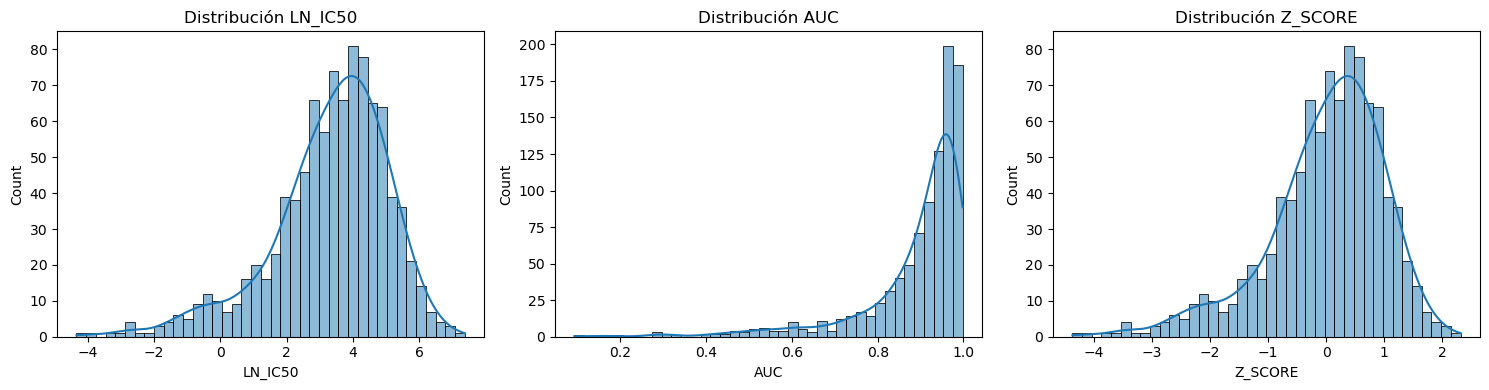

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(drug_data['LN_IC50'], ax=axes[0], bins=40, kde=True)
axes[0].set_title('Distribución LN_IC50')

sns.histplot(drug_data['AUC'], ax=axes[1], bins=40, kde=True)
axes[1].set_title('Distribución AUC')

sns.histplot(drug_data['Z_SCORE'], ax=axes[2], bins=40, kde=True)
axes[2].set_title('Distribución Z_SCORE')

plt.tight_layout()
plt.show()

# A partir de esto veo que las distribuciones de LN_IC50 y Z_SCORE son similares. 
# En cambio, AUC esta sesgada hacía 1. 
# Por lo tanto, para el modelo de predicción, me quedo con LN_IC50 como variable objetivo 
# dado que tiene mayor rango.

In [9]:
# Como el archivo es pesado, miro solo las primeras filas para entender la estructura
rna = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=5)
print(rna.shape)
print(rna.head())
print(rna.columns.tolist()[:10])  # Solo primeras 10 columnas

(5, 1901)
      model_id       Unnamed: 1 Unnamed: 2 SIDM00001 SIDM00002 SIDM00003  \
0   model_name              NaN        NaN     MEC-1   NBsusSR       M14   
1  data_source              NaN        NaN     Broad    Sanger    Sanger   
2  gene_symbol  ensembl_gene_id    gene_id       NaN       NaN       NaN   
3         A1BG  ENSG00000121410  SIDG00001     3.853    4.5059    3.9736   
4     A1BG-AS1  ENSG00000268895  SIDG00002    1.8156    2.3868    3.1408   

       SIDM00005 SIDM00006 SIDM00007 SIDM00008  ...      SIDM02262  \
0  MDA-MB-134-VI     MCC26     MCC13      MCAS  ...  WTSI-COLO_427   
1          Broad    Sanger    Sanger     Broad  ...         Sanger   
2            NaN       NaN       NaN       NaN  ...            NaN   
3         5.7038    3.9069    6.1198    0.0566  ...         0.1635   
4         3.3334    2.5801    3.5336    0.0976  ...              0   

       SIDM02263      SIDM02264        SIDM02265        SIDM02266  \
0  WTSI-COLO_425  WTSI-COLO_061  WTSI-COLIV

In [11]:
# Como las columnas 1 y 2 son metadatos, reestructuro la tabla.

# obtengo los nombres del sidm
sidm_ids = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", nrows=1, header=None)
sidm_ids = sidm_ids.iloc[0, 3:].tolist()  # desde columna 3 en adelante

# solo cojo a partir de la fila 4 para extraer la expresión génica
rna = pd.read_csv("rnaseq_merged_rsem_tpm_20260323.csv", skiprows=3, index_col=0) 

rna = rna.iloc[:, 2:]        # solo valores de expresión

# transpongo para que filas = líneas celulares, columnas = genes
rna.columns = sidm_ids
rna = rna.T
rna.index.name = 'SANGER_MODEL_ID'

print(rna.shape)
print(rna.head()) 

# Verificar duplicados
print(f"Shape: {rna.shape}")
print(f"Columnas únicas: {rna.columns.is_unique}")
print(f"Índices únicos: {rna.index.is_unique}")

(1898, 41145)
gene_symbol        A1BG  A1BG-AS1    A1CF     A2M  A2M-AS1   A2ML1  A2ML1-AS1  \
SANGER_MODEL_ID                                                                 
SIDM00001        3.8530    1.8156  0.0000  0.2388   0.0000  0.0000        0.0   
SIDM00002        4.5059    2.3868  0.0286  0.5753   0.3448  0.4751        0.0   
SIDM00003        3.9736    3.1408  0.0144  4.1326   0.4114  0.0000        0.0   
SIDM00005        5.7038    3.3334  0.0566  0.5261   1.4489  0.4114        0.0   
SIDM00006        3.9069    2.5801  0.0426  5.6562   0.5656  0.1506        0.0   

gene_symbol      A2ML1-AS2   A2MP1  A3GALT2  ...    ZXDA    ZXDB    ZXDC  \
SANGER_MODEL_ID                              ...                           
SIDM00001              0.0  0.0000   0.0000  ...  0.7655  1.9561  2.8992   
SIDM00002              0.0  0.0144   0.1890  ...  1.7137  2.6803  5.6156   
SIDM00003              0.0  0.0000   0.0841  ...  1.0909  2.1010  4.0488   
SIDM00005              0.0  0.0426   0

In [14]:
genes_duplicados = rna.columns[rna.columns.duplicated(keep=False)]
print(f"Genes duplicados: {len(genes_duplicados)}")
print(genes_duplicados.unique())
#print(rna['VARS1']) #veo que hay un error de duplicado y por se repite el gen. Promedio para eliminar una.

rna = rna.T.groupby(level=0).mean().T
print(f"Shape final: {rna.shape}")
print(f"Columnas únicas: {rna.columns.is_unique}")

Genes duplicados: 2
Index(['VARS1'], dtype='object', name='gene_symbol')
gene_symbol       VARS1   VARS1
SANGER_MODEL_ID                
SIDM00001        6.0794  6.0794
SIDM00002        6.8089  6.8089
SIDM00003        6.1568  6.1568
SIDM00005        4.8104  4.8104
SIDM00006        6.4678  6.4678
...                 ...     ...
SIDM02267        3.9477  3.9477
SIDM02268        4.0117  4.0117
SIDM02269        3.2913  3.2913
SIDM02270        5.6259  5.6259
SIDM02271        3.8288  3.8288

[1898 rows x 2 columns]
Shape final: (1898, 41144)
Columnas únicas: True


# CRUCE DE DATASETS

In [27]:
# Líneas celulares en común
sidm_rna = set(rna.index)
sidm_drug = set(drug_data['SANGER_MODEL_ID'])

comunes = sidm_rna.intersection(sidm_drug)
print(f"Líneas en RNA-seq: {len(sidm_rna)}")
print(f"Líneas en Selumetinib: {len(sidm_drug)}")
print(f"Líneas en común: {len(comunes)}")

# Filtrar ambos datasets
rna_filtered = rna.loc[rna.index.isin(comunes)].sort_index() 
drug_filtered = drug_data[drug_data['SANGER_MODEL_ID'].isin(comunes)].set_index('SANGER_MODEL_ID').sort_index()

print(f"\nShape RNA filtrado: {rna_filtered.shape}")
print(f"Shape drug filtrado: {drug_filtered.shape}")

# Verificar que el orden es idéntico en ambos
print(f"\nÍndices alineados: {(rna_filtered.index == drug_filtered.index).all()}")

print(rna_filtered.head())


Líneas en RNA-seq: 1898
Líneas en Selumetinib: 949
Líneas en común: 925

Shape RNA filtrado: (925, 41144)
Shape drug filtrado: (925, 5)

Índices alineados: True
gene_symbol        A1BG  A1BG-AS1    A1CF     A2M  A2M-AS1   A2ML1  A2ML1-AS1  \
SANGER_MODEL_ID                                                                 
SIDM00023        0.1110    0.3785  0.2388  0.0286   0.1375  0.0144        0.0   
SIDM00040        0.0704    0.2016  0.0000  0.2016   0.0841  0.0000        0.0   
SIDM00041        4.8017    2.9126  0.0286  0.2141   1.7866  0.0286        0.0   
SIDM00042        0.5059    0.8639  0.0566  0.2265   1.3561  0.4542        0.0   
SIDM00043        0.1243    0.2016  0.0144  0.0000   0.1890  0.1890        0.0   

gene_symbol      A2ML1-AS2   A2MP1  A3GALT2  ...    ZXDA    ZXDB    ZXDC  \
SANGER_MODEL_ID                              ...                           
SIDM00023              0.0  0.0286   0.0841  ...  1.5705  2.6323  4.0108   
SIDM00040              0.0  0.0000   0.0000

# LIMPIEZA DATASET: NaNs

In [ ]:
# Dataset final 
X = rna_filtered
y = drug_filtered['LN_IC50']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"¿NaN en X? {X.isna().any().any()}") 
print(f"¿NaN en y? {y.isna().any()}")

Shape X: (925, 41144)
Shape y: (925,)
¿NaN en X? True
¿NaN en y? False


In [59]:
# Cuántos NaNs hay en total
total_nan = X.isna().sum().sum()
print(f"Total NaNs: {total_nan}")

# Cuántos genes tienen NaNs
genes_con_nan = X.isna().any().sum()
print(f"Genes con algún NaN: {genes_con_nan}")

# Cuántas líneas celulares tienen NaNs
lineas_con_nan = X.isna().any(axis=1).sum()
print(f"Líneas celulares con algún NaN: {lineas_con_nan}")

Total NaNs: 2627057
Genes con algún NaN: 4728
Líneas celulares con algún NaN: 925


In [63]:
nan_por_gen = X.isna().sum()
nan_por_gen = nan_por_gen[nan_por_gen > 0]
print(f"Total genes con NaN: {len(nan_por_gen)}")
print("\nDistribución de NaNs por gen:")
print(nan_por_gen.value_counts())


Total genes con NaN: 4728

Distribución de NaNs por gen:
536    4459
925     247
389      22
Name: count, dtype: int64


Los NaNs provienen de una diferencia de panel entre laboratorios. 
A todos los genes medidos únicamente en el lab Broad (4459) le faltan exactamente las mismas líneas celulares (536). 
A todos los genes medidos únicamente en el lab Sanger (22) le faltan las mediciones de 389 líneas celulares. 
Por ello al analizar específicamente los casos con NaN, aparece que todas las lineas celulares los tienen (925). Porque Sanger presenta NaNs en 389 líneas celulares y Broad en 536 líneas celulares = 925 lineas celulares totales. 
Para continuar con el estudio, puedo eliminar esos genes o separar el análisis por laboratorio. Para esta primera aproximación eliminare los 4481 genes con NaNs, aunque a futuro podría probar analizar los datos por separado. 

In [ ]:
# Guardo los genes eliminados para referencia posterior
genes_todo_nan = X.columns[X.isna().sum() == len(X)].tolist()
genes_nan_parcial = nan_por_gen[nan_por_gen < len(X)].index.tolist()

genes_eliminados = pd.DataFrame({
    'gene_symbol': genes_todo_nan + genes_nan_parcial,
    'motivo': ['sin medicion en ninguna linea'] * len(genes_todo_nan) +
              ['sin medicion en un laboratorio'] * len(genes_nan_parcial)
})
genes_eliminados.to_csv("genes_eliminados.csv", index=False)
print(f"\nGenes eliminados guardados: {len(genes_eliminados)}")

# Eliminar genes con NaNs
X_clean = X.dropna(axis=1)
print(f"\nShape X original: {X.shape}")
print(f"Shape X limpio: {X_clean.shape}")
print(f"¿NaN restantes? {X_clean.isna().any().any()}")


Genes eliminados guardados: 4728

Shape X original: (925, 41144)
Shape X limpio: (925, 36416)
¿NaN restantes? False


### EXPLORACIÓN DEL DATASET LIMPIO

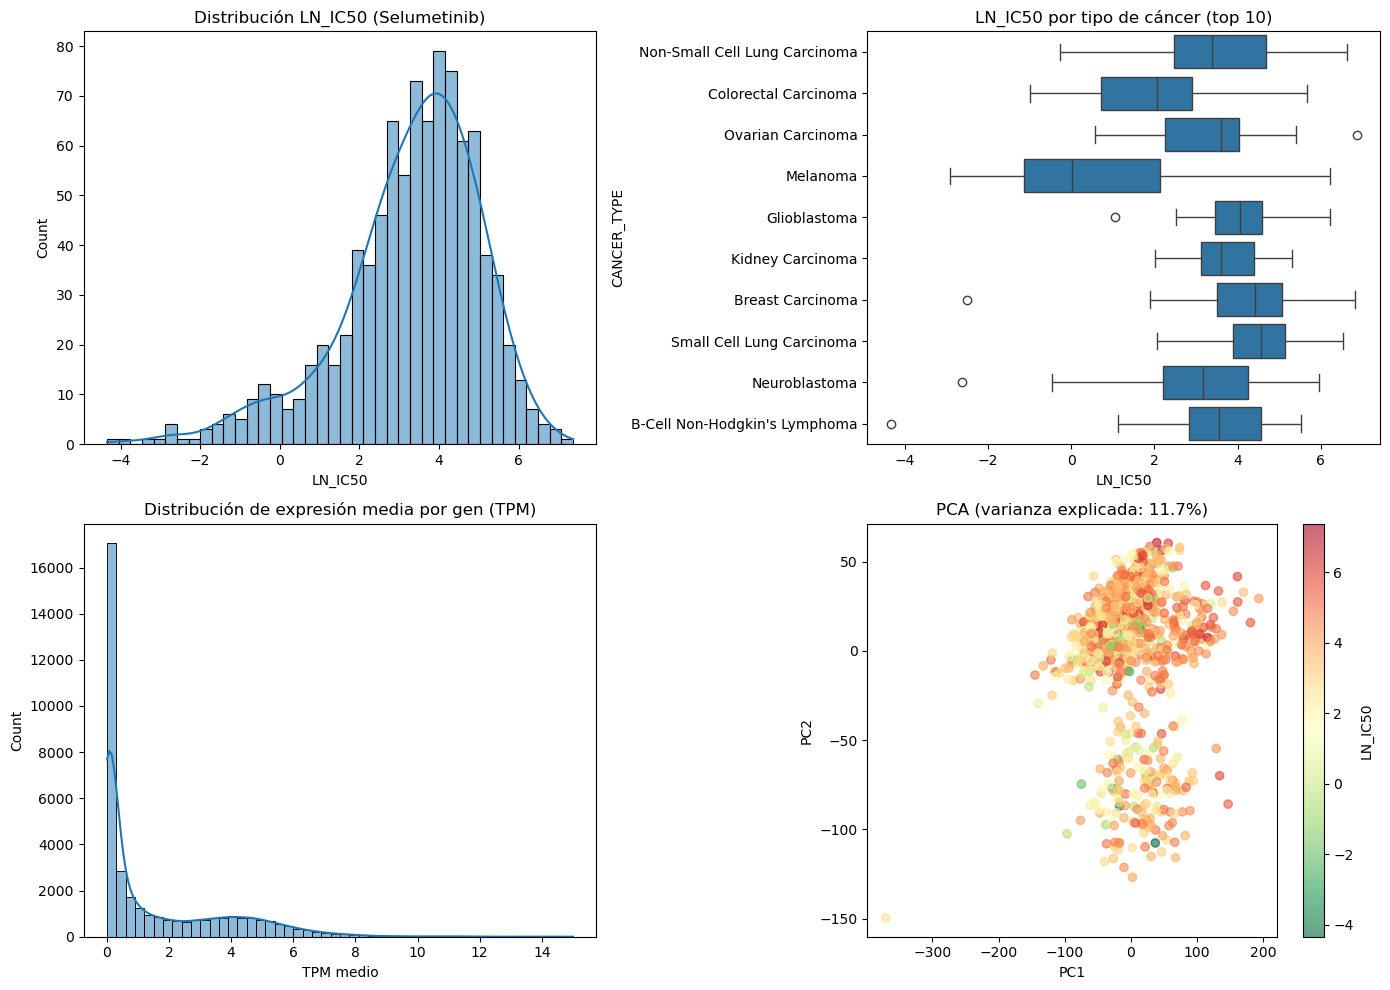

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución del target
sns.histplot(y, bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución LN_IC50 (Selumetinib)')
axes[0, 0].set_xlabel('LN_IC50')
axes[0, 0].set_ylabel('Count')

# 2. LN_IC50 por tipo de cáncer (top 10)
top_cancers = drug_filtered['CANCER_TYPE'].value_counts().head(10).index
drug_top = drug_filtered[drug_filtered['CANCER_TYPE'].isin(top_cancers)]
sns.boxplot(data=drug_top, x='LN_IC50', y='CANCER_TYPE', ax=axes[0, 1])
axes[0, 1].set_title('LN_IC50 por tipo de cáncer (top 10)')

# 3. Distribución media de expresión génica
gene_means = X_clean.mean(axis=0)
sns.histplot(gene_means, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de expresión media por gen (TPM)')
axes[1, 0].set_xlabel('TPM medio')

# 4. PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], 
                              c=y, cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(scatter, ax=axes[1, 1], label='LN_IC50')
axes[1, 1].set_title(f'PCA (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('exploracion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

**1. LN_IC50:**
Distribución aproximadamente normal con ligera cola izquierda. Los valores bajos (sensibles) son menos frecuentes que los resistentes, lo cual es coherente con lo visto anteriormente: la mayoría de líneas son resistentes a Selumetinib.

**2. LN_IC50 por tipo de cáncer:**
Melanoma destaca claramente con valores más bajos que el resto, es decir es el tipo de cáncer más sensible a Selumetinib. Tiene sentido porque el melanoma tiene alta frecuencia de mutaciones en la vía RAS/MAPK. El resto de tipos tienen distribuciones similares y bastante resistentes.

**3. Expresión media por gen:**
Distribución muy sesgada hacia 0, la mayoría de genes tienen expresión baja o nula en media. Esto es típico en RNA-seq y justifica un filtrado por varianza. Muchos de esos genes con expresión casi 0 no aportarán información al modelo.

**4. PCA:**
Solo explica el 11.7% de la varianza en 2 componentes, lo que indica que la estructura del espacio génico es muy compleja. El modelo necesitará más dimensiones para capturar la señal predictiva.

### FILTRO DE EXPRESIÓN Y VARIANZA 

Tras filtro expresión: (925, 19223)
Tras log-transform: (925, 19223)


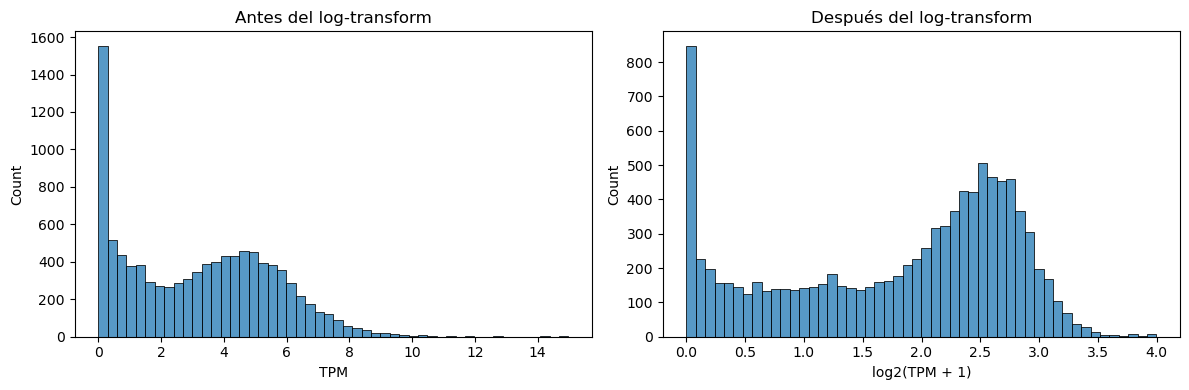

Tras filtro varianza (Q50): (925, 9611)


In [83]:
# Filtro 1: al menos 10% de muestras con TPM > 0.8
umbral_expresion = 0.8
min_muestras = int(0.10 * X_clean.shape[0])

genes_expresados = X_clean.columns[(X_clean > umbral_expresion).sum(axis=0) >= min_muestras]
X_expr = X_clean[genes_expresados]
print(f"Tras filtro expresión: {X_expr.shape}")

# Log-transform: log2(TPM + 1), el +1 evita log(0)
X_log = np.log2(X_expr + 1)
print(f"Tras log-transform: {X_log.shape}")

# Visualizar efecto del log-transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_expr.values.flatten()[:10000], bins=50, ax=axes[0])
axes[0].set_title('Antes del log-transform')
axes[0].set_xlabel('TPM')

sns.histplot(X_log.values.flatten()[:10000], bins=50, ax=axes[1])
axes[1].set_title('Después del log-transform')
axes[1].set_xlabel('log2(TPM + 1)')
plt.tight_layout()
plt.show()

# Filtro 2: varianza con Q50
gene_variance_log = X_log.var(axis=0)
umbral_varianza = gene_variance_log.quantile(0.5)
genes_variables = gene_variance_log[gene_variance_log > umbral_varianza].index
X_final = X_log[genes_variables]
print(f"Tras filtro varianza (Q50): {X_final.shape}")

In [90]:
# Comprobación final

print(f"\nResumen pipeline:")
print(f"  Genes originales:              {rna.shape[1]}")
print(f"  Tras eliminar NaNs:            {X_clean.shape[1]}")
print(f"  Tras filtro expresión:         {X_expr.shape[1]}")
print(f"  Tras filtro varianza:          {X_final.shape[1]}")
print(f"\nDataset final listo para modelar: {X_final.shape[0]} muestras x {X_final.shape[1]} genes")
print(f"\n¿NaN en X_final? {X_final.isna().any().any()}")
print(f"¿Índices alineados? {(X_final.index == y.index).all()}")


Resumen pipeline:
  Genes originales:              41144
  Tras eliminar NaNs:            36416
  Tras filtro expresión:         19223
  Tras filtro varianza:          9611

Dataset final listo para modelar: 925 muestras x 9611 genes

¿NaN en X_final? False
¿Índices alineados? True
